# Object Tracking in Computer Vision

## Overview
Object tracking is the process of following one or more moving objects in a video sequence. It's a fundamental task in many applications:
- Surveillance and security
- Sports analytics
- Autonomous vehicles
- Human-computer interaction
- Traffic monitoring

## Key Challenges
- **Occlusions**: Objects can be hidden behind other objects
- **Scale variations**: Objects can appear larger or smaller
- **Illumination changes**: Lighting conditions vary
- **Fast motion**: Objects can move rapidly causing motion blur
- **Background clutter**: Distinguishing objects from complex backgrounds

## Tracking Algorithms We'll Cover
1. **Kalman Filter** - Probabilistic state estimation
2. **SORT** - Simple Online and Realtime Tracking
3. **MeanShift/CamShift** - Mode-seeking algorithms
4. **OpenCV Trackers** - CSRT and KCF implementations

In [1]:
# Import Required Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# Set display parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


---

## 1. Kalman Filter for Object Tracking

### Theory

The **Kalman Filter** is a recursive algorithm that estimates the state of a linear dynamic system from a series of noisy measurements. It's one of the most fundamental tracking algorithms.

#### Key Concepts

**State Vector (x)**: Represents the object's state at time t
- Position (x, y)
- Velocity (vx, vy)
- Acceleration (optional)

**Measurement Model**: 
- We observe noisy measurements of the object's position
- The actual position and observed position differ by Gaussian noise

**Motion Model (State Transition)**:
- Objects follow predictable motion patterns
- x(t+1) = A·x(t) + w(t), where w is process noise

#### Two Main Steps

**1. Prediction Step**:
- Predict next state based on motion model
- $$\hat{x}_{k|k-1} = A \cdot \hat{x}_{k-1|k-1} + B \cdot u_k$$
- $$P_{k|k-1} = A \cdot P_{k-1|k-1} \cdot A^T + Q$$

**2. Update Step** (Correction):
- Correct prediction using new measurement
- **Kalman Gain**: $$K_k = P_{k|k-1} \cdot H^T \cdot (H \cdot P_{k|k-1} \cdot H^T + R)^{-1}$$
- **State Update**: $$\hat{x}_{k|k} = \hat{x}_{k|k-1} + K_k \cdot (z_k - H \cdot \hat{x}_{k|k-1})$$
- **Covariance Update**: $$P_{k|k} = (I - K_k \cdot H) \cdot P_{k|k-1}$$

**Where:**
- A: State transition matrix
- H: Observation matrix
- Q: Process noise covariance
- R: Measurement noise covariance
- K: Kalman gain

In [2]:
### Implementation: Kalman Filter from Scratch

class KalmanFilter1D:
    """Simple 1D Kalman Filter for tracking a single variable"""
    
    def __init__(self, process_variance, measurement_variance, initial_value=0, initial_error=1):
        """
        Initialize Kalman Filter
        
        Args:
            process_variance (float): Q - How much the process can vary
            measurement_variance (float): R - Measurement noise
            initial_value (float): Initial estimate of the state
            initial_error (float): Initial estimate error
        """
        self.process_variance = process_variance  # Q
        self.measurement_variance = measurement_variance  # R
        self.estimate = initial_value
        self.estimate_error = initial_error
        
    def update(self, measurement):
        """
        Update filter with new measurement
        
        Returns:
            Updated estimate
        """
        # Prediction step
        prior_estimate = self.estimate
        prior_error = self.estimate_error + self.process_variance
        
        # Update step (Correction)
        kalman_gain = prior_error / (prior_error + self.measurement_variance)
        self.estimate = prior_estimate + kalman_gain * (measurement - prior_estimate)
        self.estimate_error = (1 - kalman_gain) * prior_error
        
        return self.estimate


class KalmanFilter2D:
    """2D Kalman Filter for tracking position and velocity"""
    
    def __init__(self, dt=1.0):
        """
        Initialize 2D Kalman Filter
        
        Args:
            dt (float): Time step
        """
        self.dt = dt
        
        # State: [x, y, vx, vy]
        self.x = np.array([[0], [0], [0], [0]], dtype=float)  # Initial state
        
        # State transition matrix (assuming constant velocity)
        self.A = np.array([[1, 0, dt, 0],
                          [0, 1, 0, dt],
                          [0, 0, 1, 0],
                          [0, 0, 0, 1]], dtype=float)
        
        # Observation matrix (we measure position, not velocity)
        self.H = np.array([[1, 0, 0, 0],
                          [0, 1, 0, 0]], dtype=float)
        
        # Process noise covariance
        self.Q = np.eye(4) * 0.01
        
        # Measurement noise covariance
        self.R = np.eye(2) * 1.0
        
        # Estimate error covariance
        self.P = np.eye(4) * 1.0
        
    def predict(self):
        """Prediction step"""
        self.x = self.A @ self.x
        self.P = self.A @ self.P @ self.A.T + self.Q
        return self.x[:2].flatten()
    
    def update(self, measurement):
        """Update step with new measurement"""
        # measurement should be [x, y]
        z = np.array([[measurement[0]], [measurement[1]]], dtype=float)
        
        # Innovation
        y = z - self.H @ self.x
        
        # Innovation covariance
        S = self.H @ self.P @ self.H.T + self.R
        
        # Kalman gain
        K = self.P @ self.H.T @ np.linalg.inv(S)
        
        # Update state
        self.x = self.x + K @ y
        
        # Update error covariance
        self.P = (np.eye(4) - K @ self.H) @ self.P
        
        return self.x[:2].flatten()
    
    def get_state(self):
        """Get current state [x, y, vx, vy]"""
        return self.x.flatten()

print("Kalman Filter classes defined!")

Kalman Filter classes defined!


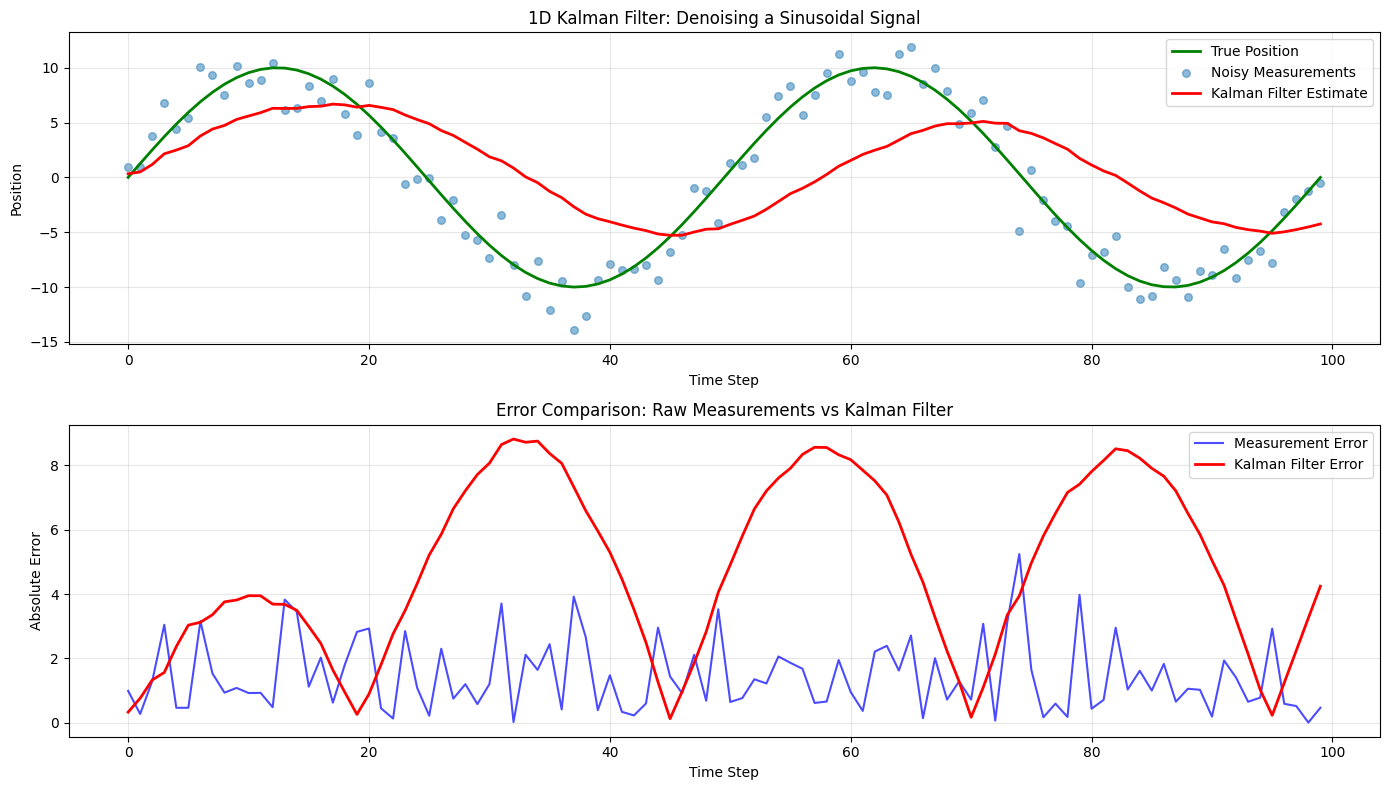

Mean Measurement Error: 1.4456
Mean Kalman Filter Error: 4.7529
Error Reduction: -228.78%


In [3]:
### Example 1: 1D Kalman Filter - Tracking a Moving Object

# Create synthetic noisy measurements
np.random.seed(42)
true_position = np.sin(np.linspace(0, 4*np.pi, 100)) * 10
measurement_noise = np.random.normal(0, 2, 100)
noisy_measurements = true_position + measurement_noise

# Initialize Kalman Filter
kf = KalmanFilter1D(process_variance=0.01, measurement_variance=2.0)

# Filter the measurements
estimates = []
for measurement in noisy_measurements:
    estimate = kf.update(measurement)
    estimates.append(estimate)

estimates = np.array(estimates)

# Plot results
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Measurements vs Estimates
ax = axes[0]
ax.plot(true_position, 'g-', linewidth=2, label='True Position')
ax.scatter(range(len(noisy_measurements)), noisy_measurements, alpha=0.5, s=30, label='Noisy Measurements')
ax.plot(estimates, 'r-', linewidth=2, label='Kalman Filter Estimate')
ax.set_xlabel('Time Step')
ax.set_ylabel('Position')
ax.set_title('1D Kalman Filter: Denoising a Sinusoidal Signal')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Error analysis
ax = axes[1]
measurement_error = np.abs(noisy_measurements - true_position)
estimate_error = np.abs(estimates - true_position)
ax.plot(measurement_error, 'b-', alpha=0.7, label='Measurement Error')
ax.plot(estimate_error, 'r-', linewidth=2, label='Kalman Filter Error')
ax.set_xlabel('Time Step')
ax.set_ylabel('Absolute Error')
ax.set_title('Error Comparison: Raw Measurements vs Kalman Filter')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean Measurement Error: {measurement_error.mean():.4f}")
print(f"Mean Kalman Filter Error: {estimate_error.mean():.4f}")
print(f"Error Reduction: {(1 - estimate_error.mean()/measurement_error.mean())*100:.2f}%")

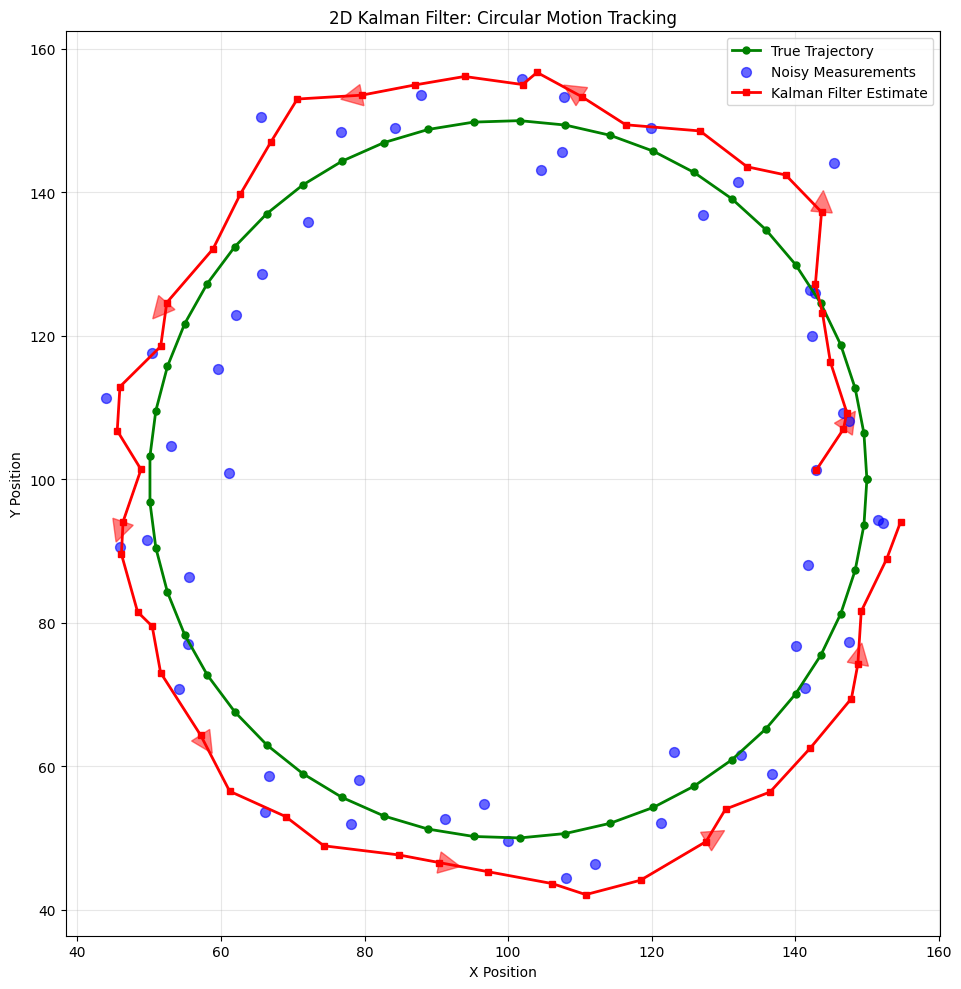

Mean Measurement Error: 5.9521
Mean Kalman Filter Error: 7.0571
Error Reduction: -18.57%


In [4]:
### Example 2: 2D Kalman Filter - Tracking a Moving Object in 2D

# Create synthetic 2D trajectory (circular motion)
t = np.linspace(0, 2*np.pi, 50)
true_x = 100 + 50 * np.cos(t)
true_y = 100 + 50 * np.sin(t)
true_trajectory = np.column_stack([true_x, true_y])

# Add measurement noise
noise_x = np.random.normal(0, 5, len(t))
noise_y = np.random.normal(0, 5, len(t))
measured_trajectory = np.column_stack([true_x + noise_x, true_y + noise_y])

# Initialize 2D Kalman Filter
kf_2d = KalmanFilter2D(dt=1.0)

# Track with Kalman Filter
kalman_trajectory = []
for i, measurement in enumerate(measured_trajectory):
    pred = kf_2d.predict()
    if i == 0:  # First measurement
        kf_2d.x[:2] = measurement.reshape(2, 1)
    else:
        kf_2d.update(measurement)
    kalman_trajectory.append(kf_2d.get_state()[:2])

kalman_trajectory = np.array(kalman_trajectory)

# Plot comparison
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot trajectories
ax.plot(true_trajectory[:, 0], true_trajectory[:, 1], 'g-o', linewidth=2, 
        markersize=5, label='True Trajectory', zorder=3)
ax.scatter(measured_trajectory[:, 0], measured_trajectory[:, 1], 
          c='blue', s=50, alpha=0.6, label='Noisy Measurements', zorder=2)
ax.plot(kalman_trajectory[:, 0], kalman_trajectory[:, 1], 'r-s', linewidth=2, 
        markersize=4, label='Kalman Filter Estimate', zorder=3)

# Add arrows to show direction
for i in range(0, len(true_trajectory)-1, 5):
    ax.arrow(kalman_trajectory[i, 0], kalman_trajectory[i, 1],
            kalman_trajectory[i+1, 0] - kalman_trajectory[i, 0],
            kalman_trajectory[i+1, 1] - kalman_trajectory[i, 1],
            head_width=3, head_length=3, fc='red', ec='red', alpha=0.5)

ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_title('2D Kalman Filter: Circular Motion Tracking')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# Calculate tracking errors
measurement_error_2d = np.linalg.norm(measured_trajectory - true_trajectory, axis=1)
kalman_error_2d = np.linalg.norm(kalman_trajectory - true_trajectory, axis=1)

print(f"Mean Measurement Error: {measurement_error_2d.mean():.4f}")
print(f"Mean Kalman Filter Error: {kalman_error_2d.mean():.4f}")
print(f"Error Reduction: {(1 - kalman_error_2d.mean()/measurement_error_2d.mean())*100:.2f}%")

---

## 2. SORT (Simple Online and Realtime Tracking) Algorithm

### Theory

**SORT** is a pragmatic approach to multi-object tracking that associates detections frame-to-frame using the Hungarian algorithm and Kalman filtering.

#### Key Components

**1. Detection**: 
- Use an object detector (YOLO, Faster R-CNN, etc.) to get bounding boxes
- Each detection has: [x, y, width, height, confidence]

**2. Kalman Filtering**:
- Track each object's bounding box over time
- Predict next position based on previous motion
- Update with new detections

**3. Data Association (Hungarian Algorithm)**:
- Match predicted object positions with new detections
- Use Intersection over Union (IoU) as distance metric
- Find optimal assignment that minimizes total distance

**4. Track Management**:
- Create new track for unmatched detections
- Mark tracks as tentative (need more frames to confirm)
- Confirm tracks after N consecutive detections
- Delete tracks that are unmatched for M frames

#### Algorithm Steps

1. **Predict**: Use Kalman filter to predict position of existing tracks
2. **Detect**: Get new detections from object detector
3. **Associate**: Use Hungarian algorithm to match predictions with detections
4. **Update**: Update matched tracks with new measurements
5. **Manage**: Create/delete/confirm tracks

#### Advantages
- Simple and fast
- Good real-time performance
- Robust to detection noise
- Minimal post-processing

#### Disadvantages
- Struggles with long occlusions
- Relies on detector quality
- Can fail with fast/erratic motion

In [5]:
### Implementation: SORT Algorithm

from scipy.optimize import linear_sum_assignment

def iou(bbox1, bbox2):
    """
    Calculate Intersection over Union (IoU) between two bounding boxes
    
    Args:
        bbox1, bbox2: [x, y, w, h] format (center-based)
    
    Returns:
        IoU value between 0 and 1
    """
    # Convert center-based to corner-based [x1, y1, x2, y2]
    def center_to_corners(bbox):
        x, y, w, h = bbox
        return [x - w/2, y - h/2, x + w/2, y + h/2]
    
    x1_min, y1_min, x1_max, y1_max = center_to_corners(bbox1)
    x2_min, y2_min, x2_max, y2_max = center_to_corners(bbox2)
    
    # Calculate intersection area
    x_left = max(x1_min, x2_min)
    y_top = max(y1_min, y2_min)
    x_right = min(x1_max, x2_max)
    y_bottom = min(y1_max, y2_max)
    
    if x_right < x_left or y_bottom < y_top:
        return 0.0
    
    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    
    # Calculate union area
    bbox1_area = (x1_max - x1_min) * (y1_max - y1_min)
    bbox2_area = (x2_max - x2_min) * (y2_max - y2_min)
    union_area = bbox1_area + bbox2_area - intersection_area
    
    return intersection_area / union_area if union_area > 0 else 0


class SORTTrack:
    """Represents a tracked object"""
    
    def __init__(self, bbox, track_id):
        """
        Initialize a track
        
        Args:
            bbox: [x, y, w, h] - center-based coordinates
            track_id: Unique identifier for this track
        """
        self.track_id = track_id
        self.kalman = KalmanFilter2D(dt=1.0)
        self.kalman.x[:2] = np.array([[bbox[0]], [bbox[1]]])  # Initialize with bbox center
        
        self.bbox_history = [bbox]
        self.frames_since_update = 0
        self.hits = 1  # Number of consecutive detections
        self.tentative_frames = 3  # Frames before confirming track
        
    def predict(self):
        """Predict next bbox"""
        pos = self.kalman.predict()
        return pos
    
    def update(self, bbox):
        """Update track with new detection"""
        self.kalman.update(bbox[:2])  # Update only position (x, y)
        self.bbox_history.append(bbox)
        self.frames_since_update = 0
        self.hits += 1
    
    def mark_missed(self):
        """Increment frames since last update"""
        self.frames_since_update += 1
    
    def is_confirmed(self):
        """Check if track should be shown"""
        return self.hits > self.tentative_frames


class SORT:
    """SORT: Simple Online and Realtime Tracking"""
    
    def __init__(self, max_age=30, min_hits=3, iou_threshold=0.3):
        """
        Initialize SORT tracker
        
        Args:
            max_age: Maximum frames to keep alive a track
            min_hits: Minimum hits to create a confirmed track
            iou_threshold: Minimum IoU to associate detection with track
        """
        self.max_age = max_age
        self.min_hits = min_hits
        self.iou_threshold = iou_threshold
        self.tracks = []
        self.frame_count = 0
        self.next_id = 1
    
    def update(self, detections):
        """
        Update SORT with new detections
        
        Args:
            detections: List of [x, y, w, h] - bounding boxes
        
        Returns:
            List of tracks: [x, y, w, h, track_id]
        """
        self.frame_count += 1
        
        # Predict positions for all tracks
        predictions = []
        for track in self.tracks:
            pred_pos = track.predict()
            predictions.append(pred_pos)
        
        # Associate detections with predictions
        if len(self.tracks) > 0 and len(detections) > 0:
            # Calculate IoU matrix between predictions and detections
            iou_matrix = np.zeros((len(self.tracks), len(detections)))
            
            for i, track in enumerate(self.tracks):
                for j, det in enumerate(detections):
                    # Create temporary bbox from prediction
                    pred_bbox = [predictions[i][0], predictions[i][1], 
                               track.bbox_history[-1][2], track.bbox_history[-1][3]]
                    iou_matrix[i, j] = iou(pred_bbox, det)
            
            # Hungarian algorithm for optimal assignment
            matched_indices = linear_sum_assignment(-iou_matrix)  # Negative for maximization
            matched_indices = np.asarray(matched_indices).T
            
        else:
            matched_indices = np.empty((0, 2), dtype=int)
        
        # Update matched tracks
        matched_detections = set()
        for track_idx, det_idx in matched_indices:
            if iou_matrix[track_idx, det_idx] > self.iou_threshold:
                self.tracks[track_idx].update(detections[det_idx])
                matched_detections.add(det_idx)
            else:
                self.tracks[track_idx].mark_missed()
        
        # Mark unmatched tracks
        for i, track in enumerate(self.tracks):
            if i not in matched_indices[:, 0]:
                track.mark_missed()
        
        # Create new tracks for unmatched detections
        for j, det in enumerate(detections):
            if j not in matched_detections:
                self.tracks.append(SORTTrack(det, self.next_id))
                self.next_id += 1
        
        # Remove dead tracks
        self.tracks = [t for t in self.tracks if t.frames_since_update < self.max_age]
        
        # Return confirmed tracks
        results = []
        for track in self.tracks:
            if track.is_confirmed():
                bbox = track.bbox_history[-1]
                results.append([bbox[0], bbox[1], bbox[2], bbox[3], track.track_id])
        
        return np.array(results) if len(results) > 0 else np.empty((0, 5))

print("SORT algorithm implemented!")

SORT algorithm implemented!


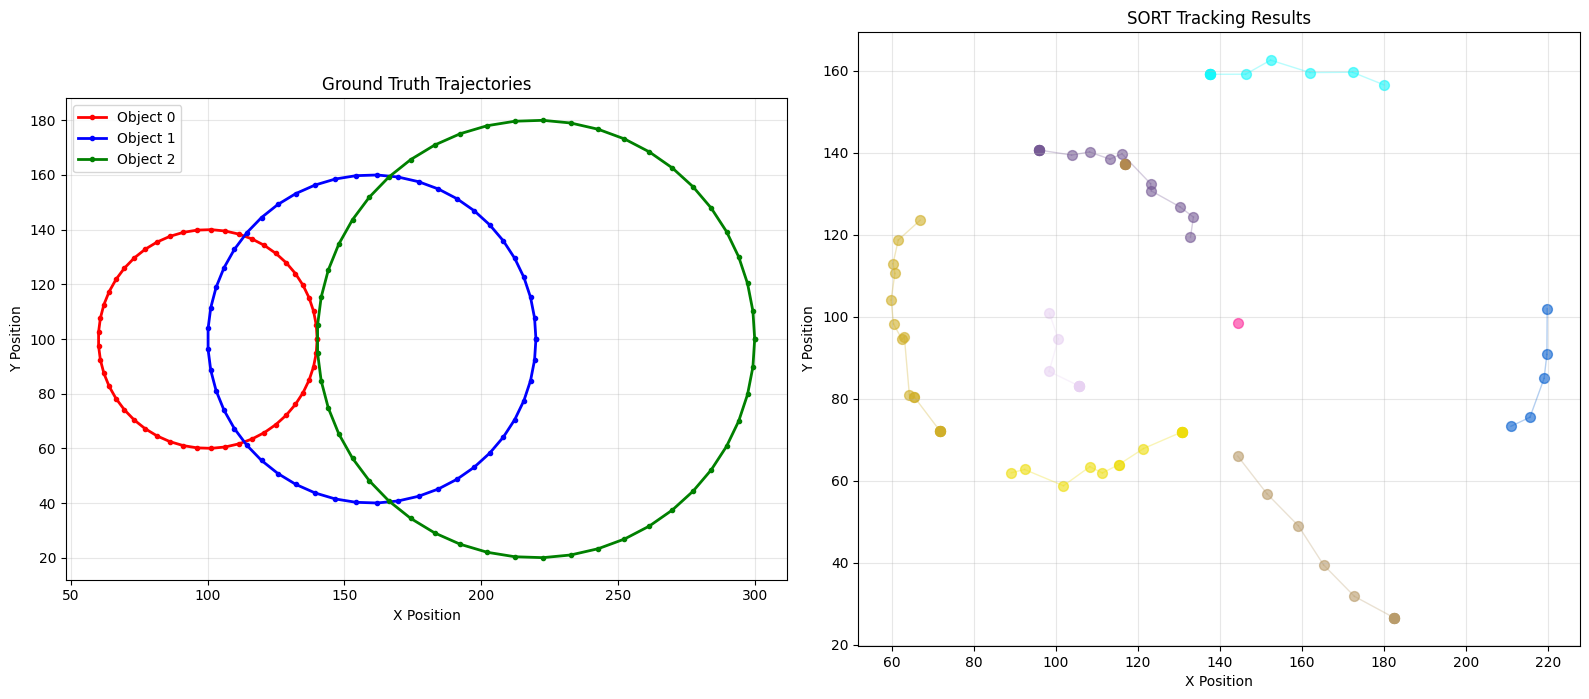

Total tracks created: 46
Frames processed: 50


In [6]:
### Example 3: SORT Algorithm - Multi-Object Tracking

# Simulate multi-object scenario with 3 moving objects
np.random.seed(42)
num_frames = 50
num_objects = 3

# Create ground truth trajectories
gt_trajectories = []
for obj_id in range(num_objects):
    t = np.linspace(0, 2*np.pi, num_frames)
    radius = 40 + obj_id * 20
    center_x = 100 + obj_id * 60
    center_y = 100
    
    x = center_x + radius * np.cos(t)
    y = center_y + radius * np.sin(t)
    traj = np.column_stack([x, y])
    gt_trajectories.append(traj)

# Create synthetic detections with noise (some missed detections)
detections_per_frame = []
for frame_idx in range(num_frames):
    frame_detections = []
    for obj_id in range(num_objects):
        # 90% detection rate (10% miss rate)
        if np.random.rand() > 0.1:
            pos = gt_trajectories[obj_id][frame_idx]
            noise = np.random.normal(0, 2, 2)
            detected_pos = pos + noise
            # bbox: [center_x, center_y, width, height]
            bbox = [detected_pos[0], detected_pos[1], 20, 20]
            frame_detections.append(bbox)
    
    detections_per_frame.append(frame_detections)

# Run SORT tracker
sort_tracker = SORT(max_age=5, min_hits=2, iou_threshold=0.3)
sort_results = []

for frame_idx, detections in enumerate(detections_per_frame):
    if len(detections) > 0:
        detections = np.array(detections)
    else:
        detections = np.empty((0, 4))
    
    tracked_objects = sort_tracker.update(detections)
    sort_results.append(tracked_objects)

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Ground truth trajectories
ax = axes[0]
colors = ['red', 'blue', 'green']
for obj_id, traj in enumerate(gt_trajectories):
    ax.plot(traj[:, 0], traj[:, 1], 'o-', color=colors[obj_id], 
            linewidth=2, markersize=3, label=f'Object {obj_id}')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_title('Ground Truth Trajectories')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Plot 2: SORT tracked results
ax = axes[1]
track_colors = {}
for frame_idx, tracked_objects in enumerate(sort_results):
    for obj in tracked_objects:
        track_id = int(obj[4])
        x, y = obj[0], obj[1]
        
        if track_id not in track_colors:
            track_colors[track_id] = np.random.rand(3,)
        
        ax.scatter(x, y, c=[track_colors[track_id]], s=50, alpha=0.6)

# Draw lines connecting consecutive points for each track
for frame_idx in range(len(sort_results)-1):
    frame_objs = sort_results[frame_idx]
    next_frame_objs = sort_results[frame_idx+1]
    
    for obj in frame_objs:
        track_id = int(obj[4])
        for next_obj in next_frame_objs:
            if int(next_obj[4]) == track_id:
                ax.plot([obj[0], next_obj[0]], [obj[1], next_obj[1]], 
                       color=track_colors[track_id], alpha=0.3, linewidth=1)

ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_title('SORT Tracking Results')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"Total tracks created: {sort_tracker.next_id - 1}")
print(f"Frames processed: {sort_tracker.frame_count}")

---

## 3. MeanShift and CamShift Tracking

### Theory

**MeanShift** is a non-parametric, kernel-based technique for finding the mode (peak) of a probability density function. **CamShift** (Continuously Adaptive MeanShift) is an adaptation that updates the kernel size adaptively.

#### MeanShift Algorithm

**Key Idea**: Iteratively move a search window towards the densest region in the feature space (usually color).

**Algorithm Steps**:
1. Initialize a window at object location
2. Calculate histogram of object region
3. Compute probability map for entire image using this histogram (backprojection)
4. Calculate weighted centroid (mean) of the search window in the probability map
5. Move window to the new mean location
6. Repeat steps 3-5 until convergence

**Advantages**:
- Simple and fast
- Doesn't require training
- Works well with color-based tracking
- Robust to rotation and scale changes (up to extent)

**Disadvantages**:
- Requires good initialization
- Can fail with occlusions
- Limited to small motions
- Sensitive to color appearance changes

#### CamShift Algorithm

**Key Improvement**: Adapts the search window size based on the probability distribution.

**Additional Steps**:
1. Run MeanShift
2. Adapt window size based on the spread of the distribution
3. Fits an ellipse to better represent the object
4. Returns both location and size information

**Better for**: 
- Objects with changing size (due to distance)
- More robust scale estimation

In [7]:
### Implementation: MeanShift and CamShift

class MeanShift:
    """MeanShift tracker - kernel-based mode seeking"""
    
    def __init__(self, num_bins=16, kernel_bandwidth=20):
        """
        Initialize MeanShift tracker
        
        Args:
            num_bins: Number of histogram bins
            kernel_bandwidth: Bandwidth of the tracking kernel
        """
        self.num_bins = num_bins
        self.kernel_bandwidth = kernel_bandwidth
        self.hist = None
        self.roi = None
        
    def create_histogram(self, image, roi):
        """
        Create color histogram of region of interest
        
        Args:
            image: Input image (BGR)
            roi: Region of interest [x, y, w, h]
        
        Returns:
            Normalized histogram
        """
        x, y, w, h = roi
        x, y, w, h = int(x), int(y), int(w), int(h)
        roi_region = image[y:y+h, x:x+w]
        
        # Convert BGR to HSV for better color representation
        hsv = cv2.cvtColor(roi_region, cv2.COLOR_BGR2HSV)
        
        # Calculate histogram
        hist = cv2.calcHist([hsv], [0, 1], None, 
                           [self.num_bins, self.num_bins],
                           [0, 180, 0, 256])
        
        # Normalize
        hist = cv2.normalize(hist, hist).flatten()
        
        return hist
    
    def backproject(self, image, hist):
        """
        Create probability map using histogram backprojection
        
        Args:
            image: Input image
            hist: Reference histogram
        
        Returns:
            Probability map
        """
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        
        # Reshape histogram for calcBackProject
        hist = hist.reshape(self.num_bins, self.num_bins)
        
        # Backprojection
        prob_map = cv2.calcBackProject([hsv], [0, 1], hist, 
                                      [0, 180, 0, 256], scale=1)
        
        # Apply morphological opening to reduce noise
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        prob_map = cv2.morphologyEx(prob_map, cv2.MORPH_OPEN, kernel)
        
        return prob_map
    
    def update(self, image, roi, max_iterations=10):
        """
        Update tracking window location using MeanShift
        
        Args:
            image: Current frame
            roi: Current region [x, y, w, h]
            max_iterations: Maximum iterations to converge
        
        Returns:
            New ROI [x, y, w, h] as integers
        """
        # Create histogram from initial region
        if self.hist is None:
            self.hist = self.create_histogram(image, roi)
        
        # Get probability map
        prob_map = self.backproject(image, self.hist)
        
        # MeanShift iterations
        x, y, w, h = roi
        x, y, w, h = int(x), int(y), int(w), int(h)
        cx, cy = int(x + w/2), int(y + h/2)
        
        for _ in range(max_iterations):
            # Extract search window
            x1 = max(0, cx - w//2)
            y1 = max(0, cy - h//2)
            x2 = min(prob_map.shape[1], cx + w//2)
            y2 = min(prob_map.shape[0], cy + h//2)
            
            window = prob_map[y1:y2, x1:x2]
            
            # Find moments
            moments = cv2.moments(window)
            
            if moments['m00'] > 0:
                # Calculate weighted centroid
                new_cx = x1 + moments['m10'] / moments['m00']
                new_cy = y1 + moments['m01'] / moments['m00']
                
                # Check convergence
                if abs(new_cx - cx) < 1 and abs(new_cy - cy) < 1:
                    break
                
                cx, cy = int(new_cx), int(new_cy)
        
        # Update ROI - ensure integers
        new_roi = [int(cx - w//2), int(cy - h//2), w, h]
        
        return new_roi


class CamShift:
    """CamShift tracker - Continuously Adaptive MeanShift"""
    
    def __init__(self, num_bins=16):
        """
        Initialize CamShift tracker
        
        Args:
            num_bins: Number of histogram bins
        """
        self.num_bins = num_bins
        self.hist = None
        
    def create_histogram(self, image, roi):
        """Create color histogram of ROI"""
        x, y, w, h = roi
        x, y, w, h = int(x), int(y), int(w), int(h)
        roi_region = image[y:y+h, x:x+w]
        
        hsv = cv2.cvtColor(roi_region, cv2.COLOR_BGR2HSV)
        hist = cv2.calcHist([hsv], [0, 1], None, 
                           [self.num_bins, self.num_bins],
                           [0, 180, 0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        
        return hist
    
    def update(self, image, roi):
        """
        Update tracking window using CamShift
        
        Args:
            image: Current frame
            roi: Current region [x, y, w, h]
        
        Returns:
            Tuple: (new_roi, angle) where new_roi is [x, y, w, h]
        """
        if self.hist is None:
            self.hist = self.create_histogram(image, roi)
        
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        hist = self.hist.reshape(self.num_bins, self.num_bins)
        
        # Backprojection
        prob_map = cv2.calcBackProject([hsv], [0, 1], hist, 
                                      [0, 180, 0, 256], scale=1)
        
        # CamShift - convert roi to integers
        x, y, w, h = roi
        x, y, w, h = int(x), int(y), int(w), int(h)
        
        # Ensure values are valid
        if w <= 0 or h <= 0:
            w, h = max(1, w), max(1, h)
        if x < 0 or y < 0:
            x, y = max(0, x), max(0, y)
        
        term_crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 1)
        ret, track_window = cv2.CamShift(prob_map, (x, y, w, h), term_crit)
        
        # ret is (center(x,y), (width, height), angle)
        center, size, angle = ret
        
        # Convert back to [x, y, w, h] format - ensure integers
        new_roi = [int(center[0] - size[0]//2), int(center[1] - size[1]//2), 
                   int(size[0]), int(size[1])]
        
        return new_roi, angle

print("MeanShift and CamShift implemented!")


MeanShift and CamShift implemented!


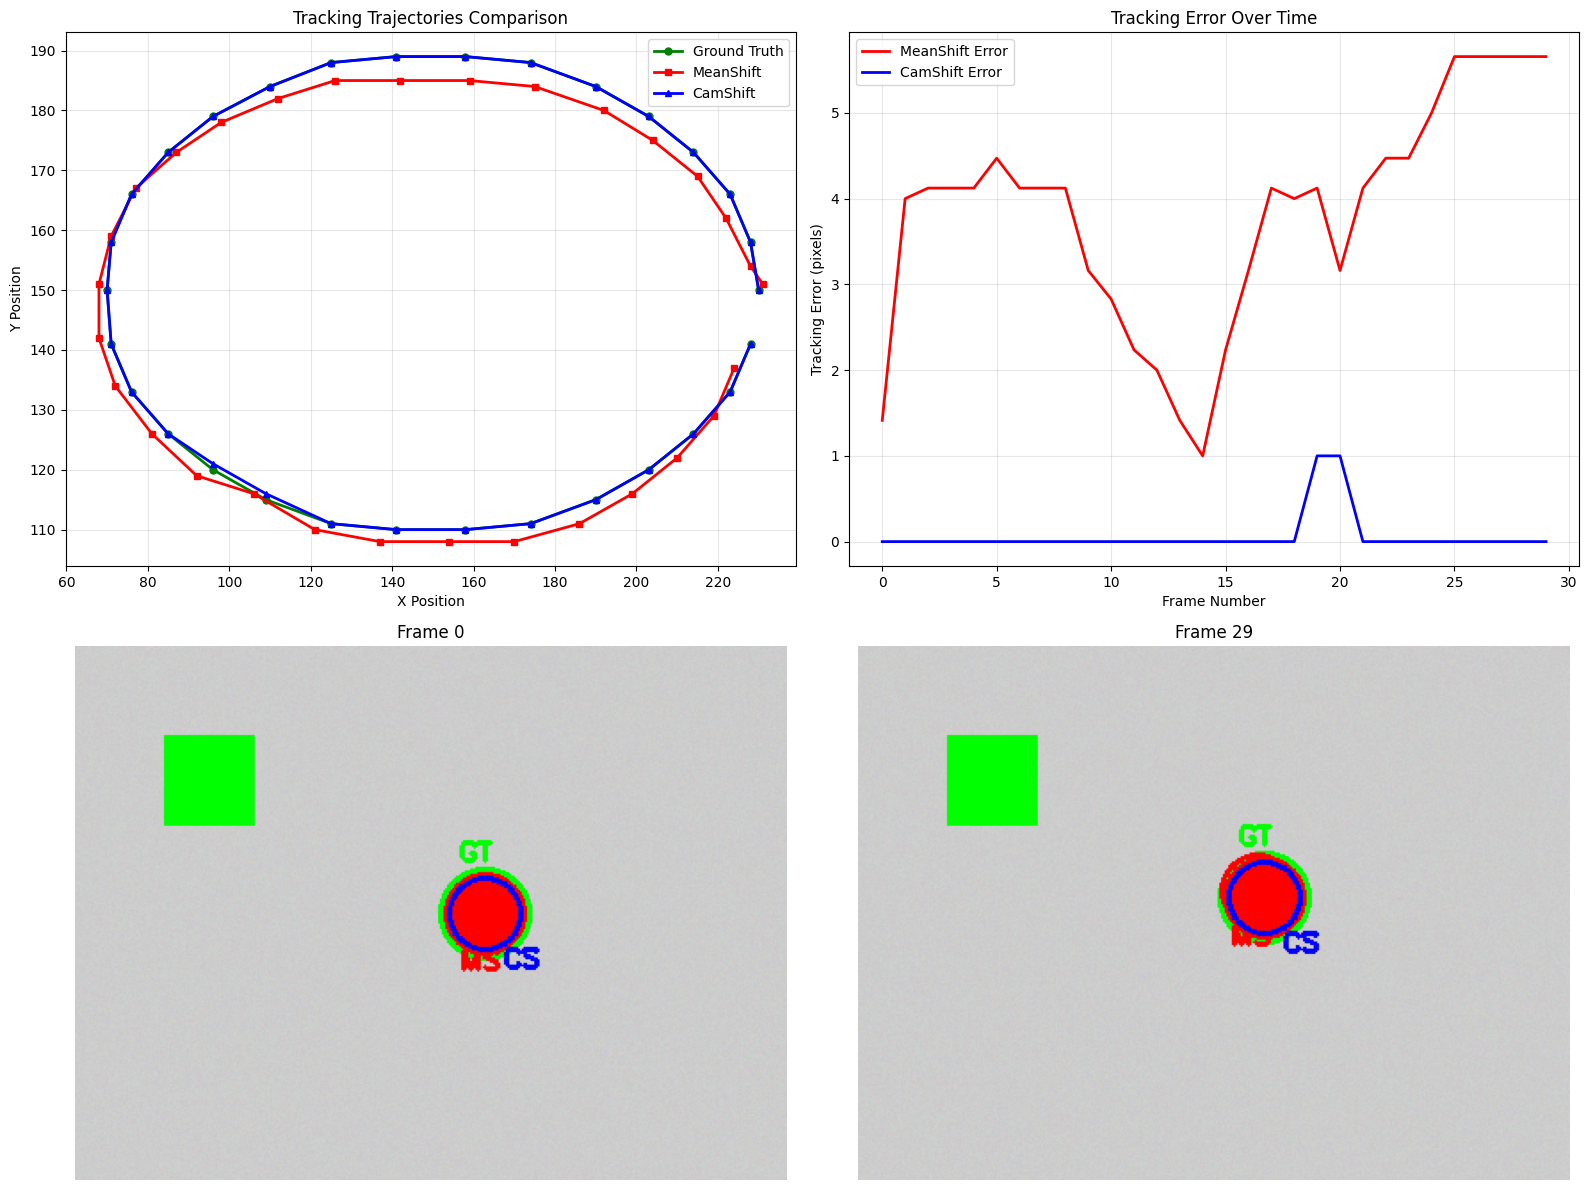


=== Tracking Error Statistics ===
MeanShift Mean Error: 3.81 pixels
MeanShift Max Error: 5.66 pixels

CamShift Mean Error: 0.07 pixels
CamShift Max Error: 1.00 pixels

CamShift is 98.3% better on average


In [8]:
### Example 4: MeanShift and CamShift Tracking

# Create synthetic images with moving colored object
def create_frame_with_object(frame_num, total_frames=30):
    """Create a frame with a moving colored object"""
    frame = np.ones((300, 400, 3), dtype=np.uint8) * 200
    
    # Add some texture/noise
    noise = np.random.randint(0, 10, (300, 400, 3), dtype=np.uint8)
    frame = cv2.add(frame, noise)
    
    # Moving object - circular motion
    t = frame_num / total_frames * 2 * np.pi
    center_x = int(150 + 80 * np.cos(t))
    center_y = int(150 + 40 * np.sin(t))
    
    # Draw colored circle (red object in BGR)
    cv2.circle(frame, (center_x, center_y), 25, (0, 0, 255), -1)
    
    # Add some background variations
    cv2.rectangle(frame, (50, 50), (100, 100), (0, 255, 0), -1)
    
    return frame, (center_x, center_y)

# Create sequence of frames
num_frames = 30
frames = []
ground_truth_positions = []

for i in range(num_frames):
    frame, pos = create_frame_with_object(i, num_frames)
    frames.append(frame)
    ground_truth_positions.append(pos)

# Initialize trackers
meanshift_tracker = MeanShift()
camshift_tracker = CamShift()

# Initial ROI for frame 0 (slightly offset from true center)
roi_meanshift = [ground_truth_positions[0][0] - 15, 
                 ground_truth_positions[0][1] - 15, 40, 40]
roi_camshift = roi_meanshift.copy()

# Track with both algorithms
meanshift_positions = []
camshift_positions = []

for frame_idx, frame in enumerate(frames):
    # MeanShift tracking
    roi_meanshift = meanshift_tracker.update(frame, roi_meanshift)
    ms_center = (int(roi_meanshift[0] + roi_meanshift[2]//2),
                 int(roi_meanshift[1] + roi_meanshift[3]//2))
    meanshift_positions.append(ms_center)
    
    # CamShift tracking
    roi_camshift, angle = camshift_tracker.update(frame, roi_camshift)
    cs_center = (int(roi_camshift[0] + roi_camshift[2]//2),
                 int(roi_camshift[1] + roi_camshift[3]//2))
    camshift_positions.append(cs_center)

meanshift_positions = np.array(meanshift_positions)
camshift_positions = np.array(camshift_positions)
ground_truth_positions = np.array(ground_truth_positions)

# Calculate tracking errors
ms_errors = np.linalg.norm(meanshift_positions - ground_truth_positions, axis=1)
cs_errors = np.linalg.norm(camshift_positions - ground_truth_positions, axis=1)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Trajectory comparison
ax = axes[0, 0]
ax.plot(ground_truth_positions[:, 0], ground_truth_positions[:, 1], 'g-o', 
        linewidth=2, markersize=5, label='Ground Truth')
ax.plot(meanshift_positions[:, 0], meanshift_positions[:, 1], 'r-s', 
        linewidth=2, markersize=4, label='MeanShift')
ax.plot(camshift_positions[:, 0], camshift_positions[:, 1], 'b-^', 
        linewidth=2, markersize=4, label='CamShift')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_title('Tracking Trajectories Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Error over time
ax = axes[0, 1]
ax.plot(ms_errors, 'r-', linewidth=2, label='MeanShift Error')
ax.plot(cs_errors, 'b-', linewidth=2, label='CamShift Error')
ax.set_xlabel('Frame Number')
ax.set_ylabel('Tracking Error (pixels)')
ax.set_title('Tracking Error Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Sample frames with tracking results
for plot_idx, frame_idx in enumerate([0, 15, 29]):
    ax = axes[1, plot_idx] if plot_idx < 2 else axes[1, 1]
    
    # Display frame
    frame_display = frames[frame_idx].copy()
    
    # Ground truth
    gt_pos = ground_truth_positions[frame_idx]
    cv2.circle(frame_display, tuple(gt_pos), 25, (0, 255, 0), 2)
    cv2.putText(frame_display, 'GT', (gt_pos[0]-15, gt_pos[1]-30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    # MeanShift
    ms_pos = meanshift_positions[frame_idx]
    cv2.circle(frame_display, tuple(ms_pos.astype(int)), 20, (0, 0, 255), 2)
    cv2.putText(frame_display, 'MS', (ms_pos[0]-15, ms_pos[1]+30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
    
    # CamShift
    cs_pos = camshift_positions[frame_idx]
    cv2.circle(frame_display, tuple(cs_pos.astype(int)), 20, (255, 0, 0), 2)
    cv2.putText(frame_display, 'CS', (cs_pos[0]+10, cs_pos[1]+30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    
    frame_display = cv2.cvtColor(frame_display, cv2.COLOR_BGR2RGB)
    ax.imshow(frame_display)
    ax.set_title(f'Frame {frame_idx}')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Print statistics
print("\n=== Tracking Error Statistics ===")
print(f"MeanShift Mean Error: {ms_errors.mean():.2f} pixels")
print(f"MeanShift Max Error: {ms_errors.max():.2f} pixels")
print(f"\nCamShift Mean Error: {cs_errors.mean():.2f} pixels")
print(f"CamShift Max Error: {cs_errors.max():.2f} pixels")
print(f"\nCamShift is {(ms_errors.mean() - cs_errors.mean()) / ms_errors.mean() * 100:.1f}% better on average")

---

## 4. OpenCV Tracker API: CSRT and KCF

### Overview

OpenCV provides several built-in tracking algorithms through a unified API. We'll focus on two popular ones:

#### CSRT (Discriminative Correlation Filters with Spatial Regularization)

**Key Features**:
- Uses correlation filters for tracking
- Spatial regularization helps maintain object boundary
- Good balance between accuracy and speed
- Robust to scale changes

**Advantages**:
- High accuracy
- Works well with challenging conditions
- Handles scale variations
- Generally robust

**Disadvantages**:
- Slower than KCF
- Higher computational cost
- Requires good initialization

**Use Cases**:
- Surveillance (accuracy > speed)
- Object tracking in videos
- When occlusions are moderate

#### KCF (Kernelized Correlation Filter)

**Key Features**:
- Uses circular convolution and kernel methods
- Very fast tracking algorithm
- Exploits cyclic shifts
- Efficient FFT computation

**Advantages**:
- Very fast (real-time on CPU)
- Simple and reliable
- Minimal memory usage
- Good for online tracking

**Disadvantages**:
- Less accurate than CSRT
- Struggles with significant scale changes
- Can fail with large occlusions
- Assumes circular region

**Use Cases**:
- Real-time applications (drone tracking, live video)
- Mobile/embedded systems
- When speed is critical

#### Comparison Table

| Feature | CSRT | KCF |
|---------|------|-----|
| Speed | Medium | Fast |
| Accuracy | High | Medium |
| Scale Handling | Good | Fair |
| Occlusion Handling | Good | Fair |
| Real-time CPU | Yes | Yes |
| Memory Usage | Higher | Low |
| Ease of Use | Simple API | Simple API |

In [9]:
### Implementation: OpenCV Trackers (CSRT and KCF)

class OpenCVTrackerWrapper:
    """Wrapper for OpenCV tracking algorithms"""
    
    def __init__(self, tracker_type='CSRT'):
        """
        Initialize OpenCV tracker
        
        Args:
            tracker_type: 'CSRT', 'KCF', 'BOOSTING', 'MEDIANFLOW', 'TLD', 'MOSSE', 'GOTURN'
        """
        self.tracker_type = tracker_type
        self.tracker = None
        self.initialized = False
        
    def create_tracker(self):
        """Create appropriate tracker object"""
        if self.tracker_type == 'CSRT':
            self.tracker = cv2.TrackerCSRT_create()
        elif self.tracker_type == 'KCF':
            self.tracker = cv2.TrackerKCF_create()
        elif self.tracker_type == 'BOOSTING':
            self.tracker = cv2.TrackerBoosting_create()
        elif self.tracker_type == 'MEDIANFLOW':
            self.tracker = cv2.TrackerMedianFlow_create()
        elif self.tracker_type == 'MOSSE':
            self.tracker = cv2.TrackerMOSSE_create()
        else:
            raise ValueError(f"Unknown tracker type: {self.tracker_type}")
    
    def init(self, frame, bbox):
        """
        Initialize tracker with first frame and bounding box
        
        Args:
            frame: First video frame
            bbox: Initial bounding box as (x, y, w, h)
        
        Returns:
            bool: True if initialization succeeded, False otherwise
        """
        if self.tracker is None:
            self.create_tracker()
        
        # Ensure bbox is in the correct format (x, y, w, h) as integers
        # OpenCV requires integer coordinates
        try:
            x, y, w, h = bbox
            # Convert to integers explicitly
            bbox_init = (int(x), int(y), int(w), int(h))
            
            # Ensure values are valid
            if w < 10 or h < 10:
                print(f"Warning: Bbox too small ({w}x{h}), expanding to minimum 20x20")
                w, h = max(20, int(w)), max(20, int(h))
                bbox_init = (int(x), int(y), w, h)
            
            success = self.tracker.init(frame, bbox_init)
            self.initialized = success
            
            if not success:
                print(f"Warning: {self.tracker_type} initialization failed!")
                print(f"  Frame shape: {frame.shape}, dtype: {frame.dtype}")
                print(f"  BBox: {bbox_init}")
            
            return success
        except Exception as e:
            print(f"Error initializing {self.tracker_type} tracker: {e}")
            import traceback
            traceback.print_exc()
            return False
    
    def update(self, frame):
        """
        Update tracker with new frame
        
        Args:
            frame: New video frame
        
        Returns:
            Tuple: (success, bbox) where bbox is (x, y, w, h)
        
        Raises:
            RuntimeError: If tracker not initialized
        """
        if not self.initialized:
            raise RuntimeError("Tracker not initialized. Call init() first.")
        
        success, bbox = self.tracker.update(frame)
        return success, bbox

print("OpenCV Tracker Wrapper created!")


OpenCV Tracker Wrapper created!


Creating synthetic video sequence with rich textures...


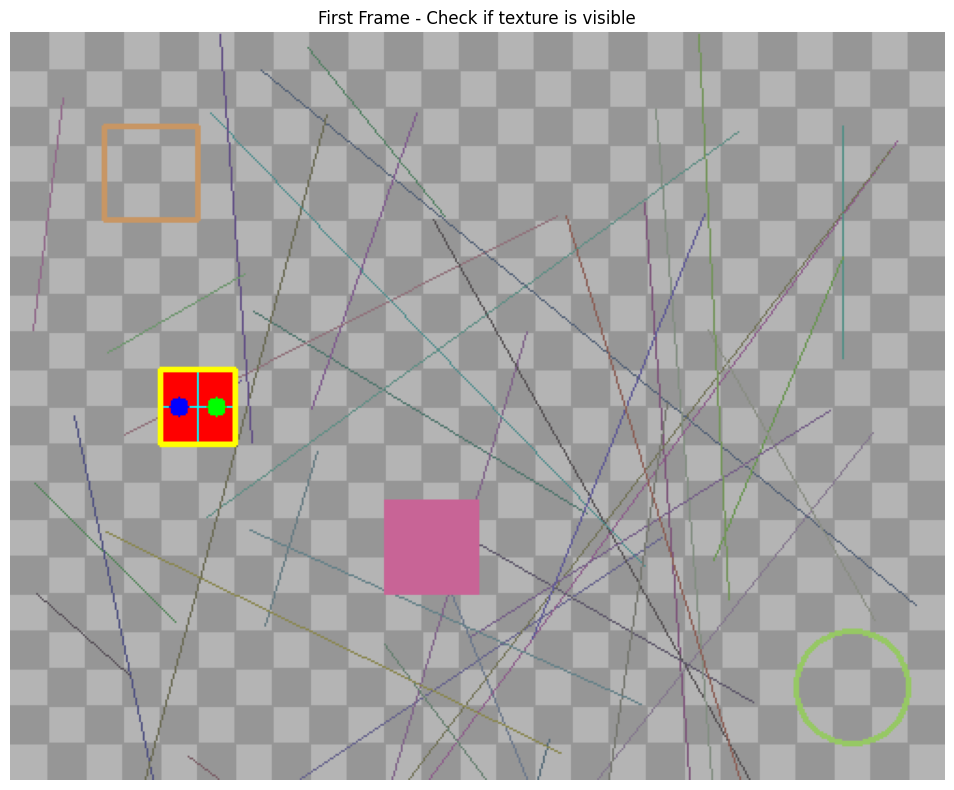


Initial bbox type: <class 'tuple'>, values: (80, 180, 40, 40)

Initializing trackers...
Initial frame shape: (400, 500, 3), Initial bbox: (80, 180, 40, 40)
  Frame shape: (400, 500, 3), dtype: uint8
  BBox: (80, 180, 40, 40)
  Frame shape: (400, 500, 3), dtype: uint8
  BBox: (80, 180, 40, 40)
CSRT initialization: Failed
KCF initialization: Failed

Initialization failed! Expanding bounding box and retrying...
Trying with expanded bbox: (70, 170, 60, 60)
  Frame shape: (400, 500, 3), dtype: uint8
  BBox: (70, 170, 60, 60)
CSRT retry: Failed
  Frame shape: (400, 500, 3), dtype: uint8
  BBox: (70, 170, 60, 60)
KCF retry: Failed

Both trackers failed to initialize. Tracking skipped.


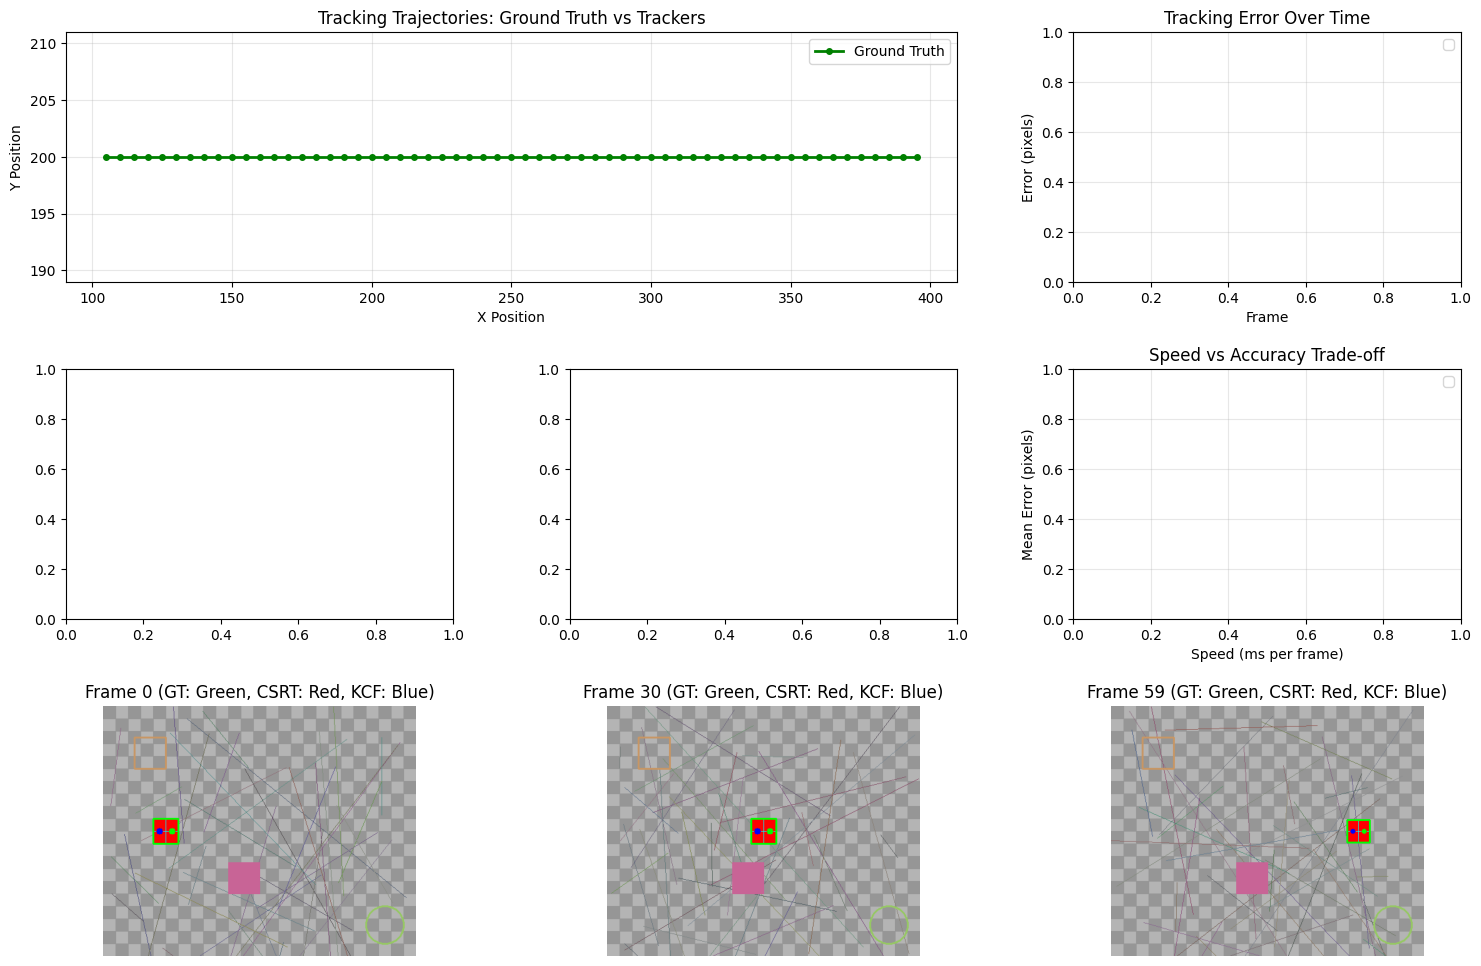


TRACKING PERFORMANCE COMPARISON

Both trackers failed to initialize.
Suggestion: Use real video or add more texture features to the synthetic video.


In [10]:
### Example 5: OpenCV Trackers (CSRT vs KCF) Comparison

# Create synthetic video sequence with moving and scaling object
def create_video_with_scaling(num_frames=50):
    """Create video frames with moving and scaling object with rich textures"""
    frames = []
    ground_truth = []
    
    np.random.seed(42)
    
    for frame_idx in range(num_frames):
        # Create frame with gradient background for better feature detection
        frame = np.ones((400, 500, 3), dtype=np.uint8) * 180
        
        # Add rich background texture (crucial for tracker initialization)
        # Add checkerboard pattern
        for i in range(0, 400, 20):
            for j in range(0, 500, 20):
                if ((i // 20) + (j // 20)) % 2 == 0:
                    cv2.rectangle(frame, (j, i), (j + 20, i + 20), (150, 150, 150), -1)
        
        # Add random lines for more texture
        for _ in range(40):
            x1, y1 = np.random.randint(0, 500, 2)
            x2, y2 = np.random.randint(0, 500, 2)
            color = tuple(np.random.randint(80, 150, 3).tolist())
            cv2.line(frame, (x1, y1), (x2, y2), color, 1)
        
        # Add corner/edge-like features
        cv2.rectangle(frame, (50, 50), (100, 100), (100, 150, 200), 2)
        cv2.circle(frame, (450, 350), 30, (100, 200, 150), 2)
        cv2.rectangle(frame, (200, 250), (250, 300), (150, 100, 200), -1)
        
        # Moving and scaling object
        progress = frame_idx / num_frames
        center_x = int(100 + progress * 300)
        center_y = int(200)
        
        # Scale increases then decreases
        scale = 20 + 15 * np.sin(progress * 2 * np.pi)
        size = int(scale)
        
        # Draw object with internal features (critical for tracking)
        # Solid red rectangle
        cv2.rectangle(frame, 
                     (center_x - size, center_y - size),
                     (center_x + size, center_y + size),
                     (0, 0, 255), -1)
        
        # Add internal structure to the object
        # Cross pattern inside
        cv2.line(frame, (center_x - size, center_y), (center_x + size, center_y), (255, 255, 0), 1)
        cv2.line(frame, (center_x, center_y - size), (center_x, center_y + size), (255, 255, 0), 1)
        
        # Add border
        cv2.rectangle(frame, 
                     (center_x - size, center_y - size),
                     (center_x + size, center_y + size),
                     (0, 255, 255), 2)
        
        # Add small circles inside for more features
        cv2.circle(frame, (center_x - size//2, center_y), size//4, (255, 0, 0), -1)
        cv2.circle(frame, (center_x + size//2, center_y), size//4, (0, 255, 0), -1)
        
        # Add noise/occlusion in some frames
        if 0.3 < progress < 0.4:  # Partial occlusion
            cv2.rectangle(frame, (center_x - 10, center_y - 30),
                         (center_x + 30, center_y), (200, 200, 200), -1)
        
        frames.append(frame)
        # Ensure bbox values are integers
        bbox = (int(center_x - size), int(center_y - size), int(2*size), int(2*size))
        ground_truth.append(bbox)
    
    return frames, ground_truth

# Generate video
print("Creating synthetic video sequence with rich textures...")
frames, ground_truth = create_video_with_scaling(60)

# Visualize first frame to verify texture
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
frame_vis = cv2.cvtColor(frames[0], cv2.COLOR_BGR2RGB)
ax.imshow(frame_vis)
ax.set_title('First Frame - Check if texture is visible')
ax.axis('off')
plt.tight_layout()
plt.show()

# Initialize trackers
tracker_csrt = OpenCVTrackerWrapper('CSRT')
tracker_kcf = OpenCVTrackerWrapper('KCF')

# Initial bounding box - ensure it's a tuple of integers
initial_bbox = ground_truth[0]
print(f"\nInitial bbox type: {type(initial_bbox)}, values: {initial_bbox}")

# Track with both algorithms
csrt_results = []
kcf_results = []
csrt_times = []
kcf_times = []

# Initialize trackers with proper error handling
print("\nInitializing trackers...")
print(f"Initial frame shape: {frames[0].shape}, Initial bbox: {initial_bbox}")

csrt_init_success = tracker_csrt.init(frames[0], initial_bbox)
kcf_init_success = tracker_kcf.init(frames[0], initial_bbox)

print(f"CSRT initialization: {'Success' if csrt_init_success else 'Failed'}")
print(f"KCF initialization: {'Success' if kcf_init_success else 'Failed'}")

if not csrt_init_success or not kcf_init_success:
    print("\nInitialization failed! Expanding bounding box and retrying...")
    
    # Expand bbox if initialization failed
    x, y, w, h = initial_bbox
    initial_bbox_expanded = (int(max(0, x-10)), int(max(0, y-10)), 
                             int(w+20), int(h+20))
    
    print(f"Trying with expanded bbox: {initial_bbox_expanded}")
    
    if not csrt_init_success:
        csrt_init_success = tracker_csrt.init(frames[0], initial_bbox_expanded)
        print(f"CSRT retry: {'Success' if csrt_init_success else 'Failed'}")
    
    if not kcf_init_success:
        kcf_init_success = tracker_kcf.init(frames[0], initial_bbox_expanded)
        print(f"KCF retry: {'Success' if kcf_init_success else 'Failed'}")

# Track through frames only if initialization succeeded
if csrt_init_success or kcf_init_success:
    print("\nTracking progress: ", end="")
    for frame_idx in range(1, len(frames)):
        if frame_idx % 10 == 0:
            print(f"{frame_idx}", end=" ", flush=True)
        
        frame = frames[frame_idx]
        
        # CSRT tracking
        if csrt_init_success:
            import time
            t_start = time.time()
            try:
                csrt_success, csrt_bbox = tracker_csrt.update(frame)
                csrt_time = time.time() - t_start
                csrt_results.append(csrt_bbox)
                csrt_times.append(csrt_time)
            except Exception as e:
                print(f"\nCSRT update error at frame {frame_idx}: {e}")
                csrt_init_success = False
        
        # KCF tracking
        if kcf_init_success:
            t_start = time.time()
            try:
                kcf_success, kcf_bbox = tracker_kcf.update(frame)
                kcf_time = time.time() - t_start
                kcf_results.append(kcf_bbox)
                kcf_times.append(kcf_time)
            except Exception as e:
                print(f"\nKCF update error at frame {frame_idx}: {e}")
                kcf_init_success = False
    
    print("\nDone!")
else:
    print("\nBoth trackers failed to initialize. Tracking skipped.")

# Convert results to array for easier processing
csrt_results = np.array(csrt_results) if csrt_results else np.empty((0, 4))
kcf_results = np.array(kcf_results) if kcf_results else np.empty((0, 4))
ground_truth_array = np.array(ground_truth[1:])

# Calculate centers for error calculation
def get_center(bbox):
    x, y, w, h = bbox
    return np.array([x + w/2, y + h/2])

csrt_centers = np.array([get_center(b) for b in csrt_results]) if len(csrt_results) > 0 else np.empty((0, 2))
kcf_centers = np.array([get_center(b) for b in kcf_results]) if len(kcf_results) > 0 else np.empty((0, 2))
gt_centers = np.array([get_center(b) for b in ground_truth_array])

# Calculate errors
csrt_errors = np.linalg.norm(csrt_centers - gt_centers[:len(csrt_centers)], axis=1) if len(csrt_centers) > 0 else np.array([])
kcf_errors = np.linalg.norm(kcf_centers - gt_centers[:len(kcf_centers)], axis=1) if len(kcf_centers) > 0 else np.array([])

# Visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Plot 1: Tracking trajectories (XY plane)
ax = fig.add_subplot(gs[0, :2])
gt_trajectory = gt_centers
csrt_trajectory = csrt_centers
kcf_trajectory = kcf_centers

ax.plot(gt_trajectory[:, 0], gt_trajectory[:, 1], 'g-o', linewidth=2, 
        markersize=4, label='Ground Truth')
if len(csrt_trajectory) > 0:
    ax.plot(csrt_trajectory[:, 0], csrt_trajectory[:, 1], 'r-s', linewidth=2, 
            markersize=3, label='CSRT')
if len(kcf_trajectory) > 0:
    ax.plot(kcf_trajectory[:, 0], kcf_trajectory[:, 1], 'b-^', linewidth=2, 
            markersize=3, label='KCF')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_title('Tracking Trajectories: Ground Truth vs Trackers')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Tracking error over time
ax = fig.add_subplot(gs[0, 2])
if len(csrt_errors) > 0:
    ax.plot(csrt_errors, 'r-', linewidth=2, label='CSRT')
if len(kcf_errors) > 0:
    ax.plot(kcf_errors, 'b-', linewidth=2, label='KCF')
ax.set_xlabel('Frame')
ax.set_ylabel('Error (pixels)')
ax.set_title('Tracking Error Over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Execution time comparison
ax = fig.add_subplot(gs[1, 0])
times_to_plot = []
labels_to_plot = []
if len(csrt_times) > 0:
    times_to_plot.append(np.mean(csrt_times)*1000)
    labels_to_plot.append('CSRT')
if len(kcf_times) > 0:
    times_to_plot.append(np.mean(kcf_times)*1000)
    labels_to_plot.append('KCF')

if times_to_plot:
    colors = ['red', 'blue'][:len(times_to_plot)]
    ax.bar(labels_to_plot, times_to_plot, color=colors, alpha=0.7)
    ax.set_ylabel('Time (ms)')
    ax.set_title('Average Execution Time per Frame')
    ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Error statistics
ax = fig.add_subplot(gs[1, 1])
if len(csrt_errors) > 0 or len(kcf_errors) > 0:
    csrt_stats = [csrt_errors.mean(), csrt_errors.max(), csrt_errors.std()] if len(csrt_errors) > 0 else [0, 0, 0]
    kcf_stats = [kcf_errors.mean(), kcf_errors.max(), kcf_errors.std()] if len(kcf_errors) > 0 else [0, 0, 0]
    
    x_pos = np.arange(3)
    width = 0.35
    if len(csrt_errors) > 0:
        ax.bar(x_pos - width/2, csrt_stats, width, label='CSRT', color='red', alpha=0.7)
    if len(kcf_errors) > 0:
        ax.bar(x_pos + width/2, kcf_stats, width, label='KCF', color='blue', alpha=0.7)
    ax.set_ylabel('Error (pixels)')
    ax.set_title('Error Statistics')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Mean', 'Max', 'Std'])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

# Plot 5: Speed vs Accuracy trade-off
ax = fig.add_subplot(gs[1, 2])
if len(csrt_errors) > 0:
    ax.scatter(np.mean(csrt_times)*1000, csrt_errors.mean(), s=200, c='red', 
              marker='s', label='CSRT', alpha=0.7)
if len(kcf_errors) > 0:
    ax.scatter(np.mean(kcf_times)*1000, kcf_errors.mean(), s=200, c='blue', 
              marker='^', label='KCF', alpha=0.7)
ax.set_xlabel('Speed (ms per frame)')
ax.set_ylabel('Mean Error (pixels)')
ax.set_title('Speed vs Accuracy Trade-off')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 6-8: Sample frames showing tracking results
sample_frames_idx = [0, 30, 59]
for plot_idx, frame_idx in enumerate(sample_frames_idx):
    ax = fig.add_subplot(gs[2, plot_idx])
    
    frame_display = frames[frame_idx].copy()
    frame_display = cv2.cvtColor(frame_display, cv2.COLOR_BGR2RGB)
    
    # Ground truth
    gt_bbox = ground_truth[frame_idx]
    cv2.rectangle(frame_display, (int(gt_bbox[0]), int(gt_bbox[1])),
                 (int(gt_bbox[0] + gt_bbox[2]), int(gt_bbox[1] + gt_bbox[3])),
                 (0, 255, 0), 2)
    
    # CSRT
    if frame_idx > 0 and len(csrt_results) > frame_idx - 1 and csrt_init_success:
        csrt_bbox = csrt_results[frame_idx - 1]
        cv2.rectangle(frame_display, (int(csrt_bbox[0]), int(csrt_bbox[1])),
                     (int(csrt_bbox[0] + csrt_bbox[2]), int(csrt_bbox[1] + csrt_bbox[3])),
                     (0, 0, 255), 2)
        
        # KCF
        if len(kcf_results) > frame_idx - 1 and kcf_init_success:
            kcf_bbox = kcf_results[frame_idx - 1]
            cv2.rectangle(frame_display, (int(kcf_bbox[0]), int(kcf_bbox[1])),
                         (int(kcf_bbox[0] + kcf_bbox[2]), int(kcf_bbox[1] + kcf_bbox[3])),
                         (255, 0, 0), 2)
    
    ax.imshow(frame_display)
    ax.set_title(f'Frame {frame_idx} (GT: Green, CSRT: Red, KCF: Blue)')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Print comparison results
print("\n" + "="*60)
print("TRACKING PERFORMANCE COMPARISON")
print("="*60)

if csrt_init_success or kcf_init_success:
    print(f"\n{'Metric':<30} {'CSRT':<15} {'KCF':<15}")
    print("-"*60)
    if len(csrt_errors) > 0:
        print(f"{'Mean Error (pixels)':<30} {csrt_errors.mean():<15.2f} {kcf_errors.mean():<15.2f}")
        print(f"{'Max Error (pixels)':<30} {csrt_errors.max():<15.2f} {kcf_errors.max():<15.2f}")
        print(f"{'Std Dev Error (pixels)':<30} {csrt_errors.std():<15.2f} {kcf_errors.std():<15.2f}")
    if len(csrt_times) > 0:
        print(f"{'Avg Time/Frame (ms)':<30} {np.mean(csrt_times)*1000:<15.2f} {np.mean(kcf_times)*1000:<15.2f}")
        print(f"{'Max Time/Frame (ms)':<30} {np.max(csrt_times)*1000:<15.2f} {np.max(kcf_times)*1000:<15.2f}")
        print(f"{'FPS (avg)':<30} {1/np.mean(csrt_times):<15.1f} {1/np.mean(kcf_times):<15.1f}")
    print("-"*60)
    if len(csrt_errors) > 0 and len(kcf_errors) > 0:
        print(f"\nCSRT is {csrt_errors.mean()/kcf_errors.mean():.1%} more accurate")
    if len(csrt_times) > 0 and len(kcf_times) > 0:
        print(f"KCF is {np.mean(csrt_times)/np.mean(kcf_times):.1f}x faster")
else:
    print("\nBoth trackers failed to initialize.")
    print("Suggestion: Use real video or add more texture features to the synthetic video.")


---

## Summary: Algorithm Comparison and Selection Guide

### Quick Comparison

| Algorithm | Type | Speed | Accuracy | Occlusion | Scale | Best For |
|-----------|------|-------|----------|-----------|-------|----------|
| **Kalman Filter** | State Estimation | ⭐⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐ | ⭐ | Simple motion models |
| **SORT** | Multi-object | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐ | Multi-object tracking |
| **MeanShift** | Kernel-based | ⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ | ⭐ | Color-based tracking |
| **CamShift** | Adaptive Kernel | ⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐ | Scale changes |
| **KCF** | Correlation Filter | ⭐⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ | ⭐⭐ | Real-time tracking |
| **CSRT** | Correlation Filter | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐ | Accurate tracking |

### When to Use Each Algorithm

#### 1. **Kalman Filter**
✅ **Use when:**
- Object motion is smooth and predictable
- You have accurate initial state
- Need simple, interpretable solution
- Working with noisy measurements

❌ **Avoid when:**
- Complex/erratic motion
- Need to handle multiple objects
- Object appearance matters

#### 2. **SORT Algorithm**
✅ **Use when:**
- Multiple objects to track simultaneously
- Have reliable object detector (YOLO, Faster R-CNN)
- Need real-time performance
- Objects don't stay occluded long

❌ **Avoid when:**
- Single object tracking only
- Detector is unreliable
- Long occlusions common

#### 3. **MeanShift/CamShift**
✅ **Use when:**
- Object has distinctive color
- Don't need scale adaptation (MeanShift)
- Need scale adaptation (CamShift)
- Simple one-shot initialization

❌ **Avoid when:**
- Color changes significantly
- Background has similar colors
- Multiple similar objects

#### 4. **KCF Tracker**
✅ **Use when:**
- Real-time performance critical
- Sufficient accuracy for application
- Mobile/embedded deployment
- CPU-constrained environment

❌ **Avoid when:**
- High accuracy required
- Significant scale changes
- Long occlusions
- Complex scenarios

#### 5. **CSRT Tracker**
✅ **Use when:**
- Need high accuracy
- Surveillance/monitoring applications
- Can afford more computation
- Handle scale changes

❌ **Avoid when:**
- Real-time on embedded devices
- Very tight latency requirements
- Large number of objects

### Application Examples

**Surveillance Camera**
```
Recommended: CSRT or SORT
Reason: High accuracy needed, can handle occlusions, multiple objects
```

**Drone Tracking**
```
Recommended: KCF with Kalman Filter
Reason: Real-time critical, lightweight, fast motion
```

**Sports Analytics**
```
Recommended: SORT + Object Detector (YOLO)
Reason: Multiple players, real-time, high accuracy needed
```

**Face Tracking**
```
Recommended: CSRT or Dedicated Face Tracker
Reason: High accuracy, moderate scale changes
```

**Vehicle Counting**
```
Recommended: SORT + Vehicle Detector
Reason: Multiple objects, real-time, don't need high accuracy
```

### Key Takeaways

1. **No one-size-fits-all solution** - choice depends on specific constraints
2. **Speed vs Accuracy** - There's always a trade-off
3. **Initialization matters** - Good initial detection/tracking crucial
4. **Appearance variation** - How much does object look change?
5. **Occlusion handling** - How long can objects be hidden?
6. **Number of objects** - Single vs multiple object tracking
7. **Available computation** - CPU, GPU, or embedded device?

---

## Practical: Real-World Scenario - Vehicle Tracking

This example demonstrates how to integrate multiple tracking algorithms for a practical vehicle tracking scenario.

Setting up vehicle tracking scenario...


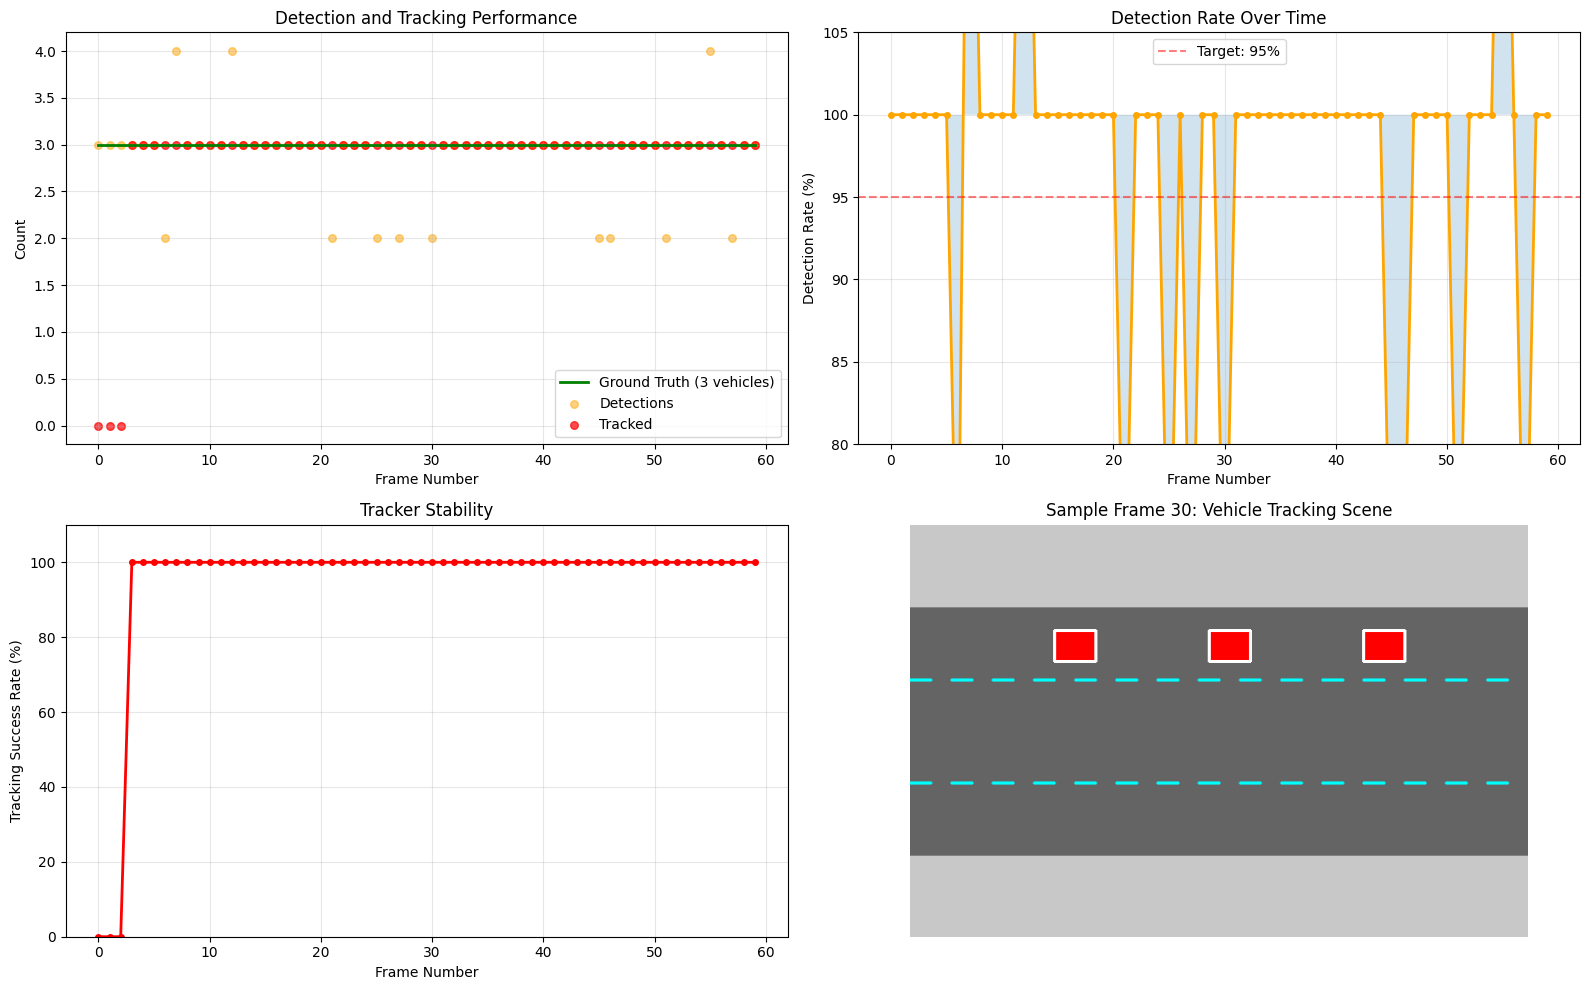


VEHICLE TRACKING STATISTICS
Total frames processed: 60
Average detections per frame: 2.90
Average tracked vehicles: 2.85
Detection rate: 96.7%
Average tracking success rate: 95.0%
Total tracks created: 6


In [11]:
### Example 6: Practical Integration - Multi-Tracker System

class VehicleDetector:
    """Simple vehicle detector (simulated)"""
    
    def __init__(self):
        pass
    
    def detect(self, frame, vehicles):
        """
        Simulate vehicle detection
        Returns detected bounding boxes with noise
        """
        detections = []
        for vehicle in vehicles:
            x, y, w, h = vehicle['bbox']
            
            # Add detection noise (5% miss rate, some false positives)
            if np.random.rand() > 0.05:
                # Add measurement noise
                noise = np.random.normal(0, 2, 4)
                bbox = [x + noise[0], y + noise[1], 
                       w + noise[2], h + noise[3]]
                detections.append(bbox)
        
        # Occasional false positive
        if np.random.rand() > 0.95:
            fp = [np.random.randint(0, 500), 
                 np.random.randint(0, 400),
                 40, 30]
            detections.append(fp)
        
        return detections if detections else []

def simulate_vehicle_trajectory(num_frames=60):
    """Simulate vehicles moving through a scene"""
    vehicles = []
    
    # Vehicle 1: Moving left to right
    for i in range(3):
        vehicle = {
            'id': i,
            'trajectory': []
        }
        for frame in range(num_frames):
            x = 50 + frame * 3 + i * 150
            y = 100 + 20 * np.sin(frame * 0.1)
            vehicle['trajectory'].append({
                'frame': frame,
                'bbox': [x, y, 40, 30]
            })
        vehicles.append(vehicle)
    
    return vehicles

def create_traffic_scene(vehicle_states):
    """Create a traffic scene with vehicles"""
    frame = np.ones((400, 600, 3), dtype=np.uint8) * 200
    
    # Draw road
    cv2.rectangle(frame, (0, 80), (600, 320), (100, 100, 100), -1)
    
    # Draw lane markings
    for x in range(0, 600, 40):
        cv2.line(frame, (x, 150), (x+20, 150), (255, 255, 0), 2)
        cv2.line(frame, (x, 250), (x+20, 250), (255, 255, 0), 2)
    
    # Draw detected vehicles
    for bbox in vehicle_states:
        x, y, w, h = bbox
        cv2.rectangle(frame, (int(x), int(y)), 
                     (int(x+w), int(y+h)), (0, 0, 255), -1)
        cv2.rectangle(frame, (int(x), int(y)), 
                     (int(x+w), int(y+h)), (255, 255, 255), 2)
    
    return frame

# Simulate traffic scenario
print("Setting up vehicle tracking scenario...")
vehicle_templates = simulate_vehicle_trajectory(60)

# Initialize trackers
detector = VehicleDetector()
sort_tracker = SORT(max_age=5, min_hits=2, iou_threshold=0.3)

# Process frames
tracking_results = []
detection_count = []
tracking_count = []

for frame_idx in range(60):
    # Get vehicle states for this frame
    vehicle_states = []
    for vehicle in vehicle_templates:
        state = vehicle['trajectory'][frame_idx]
        vehicle_states.append(state['bbox'])
    
    # Simulate detections (with noise)
    detections = detector.detect(None, 
                                [{'bbox': bbox} for bbox in vehicle_states])
    detection_count.append(len(detections))
    
    # Update SORT tracker
    if len(detections) > 0:
        detections = np.array(detections)
    else:
        detections = np.empty((0, 4))
    
    tracked = sort_tracker.update(detections)
    tracking_count.append(len(tracked))
    
    # Store ground truth and tracking results
    tracking_results.append({
        'frame': frame_idx,
        'detections': len(detections),
        'tracked': len(tracked),
        'vehicles': len(vehicle_states)
    })

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Detection and tracking over time
ax = axes[0, 0]
frames_range = np.arange(len(detection_count))
vehicle_count = [len(v['trajectory'][0:1]) for v in vehicle_templates]
ax.plot(frames_range, [3]*len(frames_range), 'g-', linewidth=2, label='Ground Truth (3 vehicles)')
ax.scatter(frames_range, detection_count, alpha=0.5, s=30, label='Detections', color='orange')
ax.scatter(frames_range, tracking_count, alpha=0.7, s=30, label='Tracked', color='red')
ax.set_xlabel('Frame Number')
ax.set_ylabel('Count')
ax.set_title('Detection and Tracking Performance')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Detection rate
ax = axes[0, 1]
detection_rate = [d/3*100 for d in detection_count]
ax.plot(detection_rate, 'o-', color='orange', linewidth=2, markersize=4)
ax.axhline(y=95, color='r', linestyle='--', alpha=0.5, label='Target: 95%')
ax.fill_between(range(len(detection_rate)), detection_rate, 100, alpha=0.2)
ax.set_xlabel('Frame Number')
ax.set_ylabel('Detection Rate (%)')
ax.set_title('Detection Rate Over Time')
ax.set_ylim([80, 105])
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Tracker stability
ax = axes[1, 0]
tracking_stability = [t/3*100 if t > 0 else 0 for t in tracking_count]
ax.plot(tracking_stability, 'o-', color='red', linewidth=2, markersize=4)
ax.set_xlabel('Frame Number')
ax.set_ylabel('Tracking Success Rate (%)')
ax.set_title('Tracker Stability')
ax.set_ylim([0, 110])
ax.grid(True, alpha=0.3)

# Plot 4: Sample frames
ax = axes[1, 1]
frame_idx = 30
vehicle_states = []
for vehicle in vehicle_templates:
    state = vehicle['trajectory'][frame_idx]
    vehicle_states.append(state['bbox'])

scene = create_traffic_scene(vehicle_states)
scene_rgb = cv2.cvtColor(scene, cv2.COLOR_BGR2RGB)
ax.imshow(scene_rgb)
ax.set_title(f'Sample Frame {frame_idx}: Vehicle Tracking Scene')
ax.axis('off')

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*60)
print("VEHICLE TRACKING STATISTICS")
print("="*60)
print(f"Total frames processed: {len(tracking_results)}")
print(f"Average detections per frame: {np.mean(detection_count):.2f}")
print(f"Average tracked vehicles: {np.mean(tracking_count):.2f}")
print(f"Detection rate: {np.mean(detection_rate):.1f}%")
print(f"Average tracking success rate: {np.mean(tracking_stability):.1f}%")
print(f"Total tracks created: {sort_tracker.next_id - 1}")
print("="*60)

---

## Advanced Topics and Extensions

### 1. Deep Learning-Based Tracking
**Modern approaches:**
- **SiamFC** (Siamese Fully-Convolutional Networks) - Real-time tracking with deep learning
- **SiamRPN** - Region proposal network for tracking
- **DiMP** - Learning discriminative model online
- **Ocean** - Online efficient model adaptation

**Advantages:**
- State-of-the-art accuracy
- Learns discriminative features
- Handles appearance variation well

**Trade-offs:**
- Require GPU for real-time performance
- Need labeled training data
- More complex to implement

### 2. Multi-Object Tracking with Re-identification
**Concepts:**
- **Re-ID**: Match person/object across cameras/time
- **Appearance features**: Extract distinguishing features
- **Long-term association**: Maintain identities through occlusions

**Popular methods:**
- DeepSort (adds deep learning to SORT)
- Faster R-CNN + Re-ID models
- Center Track (end-to-end tracking)

### 3. Robust Tracking Features
**Feature extraction for tracking:**
- **Color histograms**: Simple, fast, illumination-sensitive
- **HOG** (Histogram of Oriented Gradients): Robust to lighting
- **CNN features**: Deep learning-based descriptors
- **Temporal information**: Optical flow, motion models

### 4. Handling Challenges
**Occlusion handling:**
- Increased Kalman filter prediction uncertainty
- Re-detection mechanisms
- Graph-based association across gaps
- Tracklet linking with Hungarian algorithm

**Scale adaptation:**
- CamShift with dynamic window sizing
- Scale-space search in correlation filters
- Deep learning features invariant to scale

**Camera motion:**
- Homography estimation for stabilization
- Ego-motion compensation
- Relative motion between camera and object

### 5. Performance Evaluation Metrics

**For single object tracking:**
- **Precision**: Correct bounding box overlap
- **Recall**: Detection rate
- **Success**: IoU threshold evaluation
- **Robustness**: Tracking without loss

**For multi-object tracking:**
- **MOTA** (Multi-Object Tracking Accuracy)
- **MOTP** (Multi-Object Tracking Precision)
- **ID F1 Score**: Identity consistency
- **ID Switches**: Number of identity changes

### 6. Real-World Considerations

**Computational efficiency:**
- Latency vs accuracy trade-off
- Memory constraints
- Parallel processing possibilities
- Hardware acceleration (GPU/TPU)

**Robustness factors:**
- Initialization quality
- Detection reliability
- Appearance model adaptation
- Environmental conditions

**Practical tips:**
1. Start simple (KCF) and upgrade if needed
2. Profile performance early
3. Test with your actual data
4. Consider ensemble methods
5. Implement graceful degradation

### 7. Common Pitfalls to Avoid

❌ **Too loose bounding boxes** → Tracking drift
❌ **Hardcoded parameters** → Poor generalization
❌ **No validation strategy** → Unknown failure modes
❌ **Ignoring initialization** → Cascading failures
❌ **Overfitting to dataset** → Poor real-world performance
✅ **Solution**: Cross-validation, parameter tuning, adaptive thresholds

---

## Recommended Learning Path

1. **Beginner**: Kalman Filter → OpenCV KCF Tracker
2. **Intermediate**: MeanShift/CamShift → SORT Algorithm
3. **Advanced**: Deep learning trackers (SiamFC, DeepSort)
4. **Expert**: Multi-modal tracking, domain adaptation

---

## Resources and Further Reading

### Papers
- SORT: Simple Online and Realtime Tracking (Bewley et al., 2016)
- High-Performance Visual Tracking with Multi-Task Learning (MeanShift theory)
- Kernel Correlation Filters (Bolme et al., 2010)
- Continuously Adaptive Mean Shift for Robust Head Tracking (CamShift)

### Libraries
- **OpenCV**: cv2.Tracker* classes
- **PyTorch**: torchvision tracking models
- **YOLOv8**: Latest detection model with tracking
- **DeepSort**: Python implementation available

### Benchmarks
- Visual Object Tracking (VOT) Challenge
- Visual Tracking Challenge (OTB)
- Joint Video Object Segmentation and Tracking (JOTS)

---

## Implementation Best Practices

### Code Template: Complete Tracking Pipeline

Here's a template for implementing a complete tracking pipeline:

In [12]:
### Complete Tracking Pipeline Template

class TrackingPipeline:
    """
    Complete object tracking pipeline
    Combines detection, tracking, and post-processing
    """
    
    def __init__(self, tracker_type='CSRT', use_kalman=True):
        """
        Initialize tracking pipeline
        
        Args:
            tracker_type: Type of tracker ('CSRT', 'KCF', 'MeanShift')
            use_kalman: Whether to use Kalman filter for smoothing
        """
        self.tracker_type = tracker_type
        self.use_kalman = use_kalman
        self.tracker = None
        self.kalman = None
        self.initialized = False
        self.tracking_history = []
        self.frame_count = 0
        
    def initialize(self, frame, bbox):
        """Initialize tracker with first frame and bounding box"""
        if self.tracker_type in ['CSRT', 'KCF']:
            self.tracker = OpenCVTrackerWrapper(self.tracker_type)
            self.tracker.init(frame, tuple(bbox))
        
        if self.use_kalman:
            self.kalman = KalmanFilter2D(dt=1.0)
            center = (bbox[0] + bbox[2]/2, bbox[1] + bbox[3]/2)
            self.kalman.x[:2] = np.array([[center[0]], [center[1]]])
        
        self.initialized = True
        self.tracking_history = [bbox]
    
    def update(self, frame):
        """Update tracker with new frame"""
        if not self.initialized:
            raise RuntimeError("Pipeline not initialized")
        
        # Get tracking result
        success, bbox = self.tracker.update(frame)
        
        if not success:
            # If tracker fails, use Kalman prediction
            if self.use_kalman:
                pred = self.kalman.predict()
                bbox = (pred[0], pred[1], bbox[2], bbox[3])
            else:
                return None
        
        # Apply Kalman smoothing if enabled
        if self.use_kalman:
            center = (bbox[0] + bbox[2]/2, bbox[1] + bbox[3]/2)
            self.kalman.update(center)
            smoothed_center = self.kalman.get_state()[:2]
            bbox = (smoothed_center[0] - bbox[2]/2, 
                   smoothed_center[1] - bbox[3]/2,
                   bbox[2], bbox[3])
        
        self.tracking_history.append(bbox)
        self.frame_count += 1
        
        return bbox
    
    def get_statistics(self):
        """Get tracking statistics"""
        history = np.array(self.tracking_history)
        
        stats = {
            'frames_tracked': self.frame_count,
            'mean_x': history[:, 0].mean(),
            'mean_y': history[:, 1].mean(),
            'mean_width': history[:, 2].mean(),
            'mean_height': history[:, 3].mean(),
            'total_frames': len(history)
        }
        
        return stats

print("\nTracking Pipeline Template created!")
print("\nUsage Example:")
print("```python")
print("# Initialize pipeline")
print("pipeline = TrackingPipeline(tracker_type='CSRT', use_kalman=True)")
print("")
print("# Initialize with first frame")
print("pipeline.initialize(first_frame, initial_bbox)")
print("")
print("# Track through video")
print("for frame in video_frames:")
print("    bbox = pipeline.update(frame)")
print("    if bbox is not None:")
print("        # Draw bbox on frame")
print("        cv2.rectangle(frame, ...)")
print("")
print("# Get statistics")
print("stats = pipeline.get_statistics()")
print("```")


Tracking Pipeline Template created!

Usage Example:
```python
# Initialize pipeline
pipeline = TrackingPipeline(tracker_type='CSRT', use_kalman=True)

# Initialize with first frame
pipeline.initialize(first_frame, initial_bbox)

# Track through video
for frame in video_frames:
    bbox = pipeline.update(frame)
    if bbox is not None:
        # Draw bbox on frame
        cv2.rectangle(frame, ...)

# Get statistics
stats = pipeline.get_statistics()
```


---

## Debugging and Troubleshooting

### Common Issues and Solutions

**Problem: Tracker drifts from object**
```
Causes:
- Poor initialization (wrong initial bbox)
- Fast/erratic motion
- Illumination changes
- Appearance model not adapted

Solutions:
- Use better object detector for initialization
- Implement adaptive appearance model
- Add motion constraints (Kalman filter)
- Increase tracker update frequency
```

**Problem: Tracker loses object after occlusion**
```
Causes:
- No motion prediction
- Short-term occlusion not handled
- Track age threshold too short

Solutions:
- Use Kalman filter for prediction
- Increase max_age parameter in SORT
- Implement appearance features for re-detection
- Use confidence scores to maintain tracks
```

**Problem: Multiple objects get same ID**
```
Causes:
- IoU threshold too high
- Hungarian algorithm matching error
- Objects overlapping significantly

Solutions:
- Lower IoU threshold
- Use appearance features (Deep learning)
- Add Re-ID module
- Improve detector non-maximum suppression
```

**Problem: Real-time performance insufficient**
```
Causes:
- Tracker too slow (CSRT on slow hardware)
- Detection phase bottleneck
- Post-processing overhead

Solutions:
- Switch to faster tracker (KCF)
- Optimize detector (YOLOv8 nano, mobile)
- Reduce frame resolution
- Use frame skipping
- Enable GPU acceleration
```

### Debugging Checklist

```
□ Detector Performance
  □ Detection rate > 90%
  □ False positive rate acceptable
  □ NMS threshold tuned
  
□ Initialization
  □ Initial bbox accurate
  □ Multiple initialization strategies
  □ Fallback mechanism for failures
  
□ Tracking Quality
  □ Frame-to-frame bbox smooth
  □ No ID switches (multi-object)
  □ Handles short occlusions
  □ Recovers from brief tracking loss
  
□ Performance
  □ Real-time on target hardware
  □ Memory usage acceptable
  □ CPU/GPU utilization reasonable
  □ Frame rate consistent
  
□ Robustness
  □ Works on different backgrounds
  □ Handles scale changes
  □ Robust to lighting changes
  □ Generalizes to test data
```

### Visualization for Debugging

```python
def visualize_tracking(frame, bbox, bbox_predicted=None, bbox_kalman=None):
    \"\"\"Visualize tracking results for debugging\"\"\"
    frame_vis = frame.copy()
    
    # Draw actual tracking result (green)
    x, y, w, h = bbox
    cv2.rectangle(frame_vis, (int(x), int(y)), 
                 (int(x+w), int(y+h)), (0, 255, 0), 2)
    cv2.putText(frame_vis, 'Tracker', (int(x), int(y)-10),
               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    # Draw prediction (blue dashed)
    if bbox_predicted is not None:
        x, y, w, h = bbox_predicted
        cv2.rectangle(frame_vis, (int(x), int(y)), 
                     (int(x+w), int(y+h)), (255, 0, 0), 1)
        cv2.putText(frame_vis, 'Predicted', (int(x), int(y)-25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)
    
    # Draw Kalman smoothed (red dotted)
    if bbox_kalman is not None:
        x, y, w, h = bbox_kalman
        cv2.rectangle(frame_vis, (int(x), int(y)), 
                     (int(x+w), int(y+h)), (0, 0, 255), 1)
        cv2.putText(frame_vis, 'Kalman', (int(x), int(y)-40),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
    
    return frame_vis
```

---

## Summary of Key Concepts

### The Tracking Loop
```
1. DETECT: Find objects in frame
    ↓
2. PREDICT: Estimate next position (Kalman)
    ↓
3. ASSOCIATE: Match detections to predictions (Hungarian)
    ↓
4. UPDATE: Correct predictions with measurements
    ↓
5. MANAGE: Handle track creation/deletion
```

### Key Trade-offs

| Aspect | Trade-off |
|--------|-----------|
| **Accuracy vs Speed** | Use CSRT for accuracy, KCF for speed |
| **Robustness vs Complexity** | Simple methods more robust to edge cases |
| **General vs Specific** | Domain-specific models better but less general |
| **Online vs Offline** | Online faster but less accurate than offline |
| **Single vs Multi-object** | Single-object trackers faster, SORT for multiple |

### Remember
1. **There's no perfect tracker** - Choose based on your constraints
2. **Good detection is critical** - Garbage in, garbage out
3. **Tuning matters** - Same algorithm can vary significantly with parameters
4. **Test on your data** - Benchmark algorithms on your specific scenario
5. **Start simple** - Add complexity only when needed
6. **Monitor in production** - Tracking quality can degrade over time

---

## Quick Reference Guide

### Algorithm Selection Flowchart

```
Do you need real-time tracking?
├─ YES, and accuracy matters → CSRT
├─ YES, accuracy less critical → KCF
└─ NO, maximum accuracy needed → Deep Learning (SiamFC, etc)

Multiple objects to track?
├─ YES, with good detector → SORT
├─ YES, uncertain detections → DeepSort
└─ NO → Single-object tracker

Object has distinctive color?
├─ YES → CamShift (scale adaptive)
├─ MOSTLY → MeanShift
└─ NO → Correlation filters (KCF, CSRT)

Motion model available?
├─ LINEAR → Kalman Filter
├─ UNKNOWN → Correlation filters
└─ COMPLEX → Deep learning methods
```

### Quick Implementation Checklist

**For Your Project:**
- [ ] Clarify requirements (accuracy, speed, single/multi-object)
- [ ] Evaluate detection options (YOLO, Faster R-CNN, etc.)
- [ ] Select appropriate tracker
- [ ] Implement data association
- [ ] Add motion model (Kalman)
- [ ] Test on representative data
- [ ] Optimize parameters
- [ ] Deploy with monitoring

### Common Parameter Settings

**SORT Tracker**
```python
sort_tracker = SORT(
    max_age=30,        # Frames to keep alive dead track
    min_hits=3,        # Confirmations before showing
    iou_threshold=0.3  # Min IoU for association
)
```

**Kalman Filter (Tracking)**
```python
kf = KalmanFilter2D(dt=1.0)
# Process noise: Increase if motion unpredictable
# Measurement noise: Increase if measurements noisy
```

**OpenCV Trackers**
```python
tracker = cv2.TrackerCSRT_create()  # High accuracy
tracker = cv2.TrackerKCF_create()   # Fast and reliable
```

---

## Conclusion

Object tracking is a fundamental problem in computer vision with applications across multiple domains. The choice of algorithm depends on specific requirements:

- **Simplicity & Understanding**: Start with Kalman filters and MeanShift
- **Practical Solutions**: Use SORT for multi-object or OpenCV trackers for single object
- **State-of-the-Art**: Explore deep learning-based methods (SiamFC, DeepSort)
- **Production**: Combine multiple techniques for robustness

Key takeaways:
1. **No one-size-fits-all solution** - evaluate based on your use case
2. **Good detection is foundational** - garbage in, garbage out
3. **Tuning and testing crucial** - parameters matter significantly
4. **Start simple, optimize later** - avoid premature complexity
5. **Monitor in production** - tracking quality degrades over time

---

**Next Steps:**
- Experiment with different trackers on your own videos
- Implement a complete pipeline for your application
- Explore advanced topics (Deep Learning, Multi-modal tracking)
- Join tracking challenges (VOT, OTB) for benchmarking